# Constraint Penalty 模型比較

這個 notebook 用來比較原本 Fast parameter estimation NN 與加入 DeepExtrema-style constraint penalty 之後的模型。

比較對象：

- Baseline NN：`models/best_baseline_model.pth`
- Constraint penalty NN：`models/best_constraint_penalty_model.pth`

因為訓練資料的 target 是經過 median / IQR 標準化後的參數，所以這裡比較的是 standardized scale：

- $\mu^*$：標準化後的位置參數
- $\sigma^*$：標準化後的尺度參數
- $\xi$：極值理論中的 shape 參數，其中 $\xi=-c$

同時也會檢查預測出的 $\xi$ 是否落在加入 safety margin 後的 DeepExtrema 可行區間 $[\xi_{lower}, \xi_{upper}]$。

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

SRC_DIR = ROOT / "src"
sys.path.insert(0, str(SRC_DIR))

from baseline_train import GEVNet as BaselineNet
from constraint_penalty_train import GEVNet as ConstraintNet, load_constraint_dataset

MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
FIGURE_DIR = RESULT_DIR / "figures"
TABLE_DIR = RESULT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

ROOT
GRID_SEARCH_SUMMARY_PATHS = [
    TABLE_DIR / "safety_margin_grid_search_xi_summary.csv",
    TABLE_DIR / "safety_margin_grid_search_delta_summary.csv",
]
GRID_SEARCH_METRICS_PATHS = [
    TABLE_DIR / "safety_margin_grid_search_xi_metrics.csv",
    TABLE_DIR / "safety_margin_grid_search_delta_metrics.csv",
]


## 讀取 validation data

`constraint_penalty_train.py` 會額外存下每筆樣本在 standardized scale 下的最小值與最大值，這是計算 $\xi$ 上下界需要用到的資訊。

In [2]:
X, Y, extrema, n_train, n_valid, N_set = load_constraint_dataset()

X_valid = X[n_train:n_train + n_valid]
Y_valid = Y[n_train:n_train + n_valid]
extrema_valid = extrema[n_train:n_train + n_valid]

print("X_valid:", X_valid.shape)
print("Y_valid:", Y_valid.shape)
print("extrema_valid:", extrema_valid.shape)
print("N_set:", N_set)

X_valid: (40000, 11)
Y_valid: (40000, 3)
extrema_valid: (40000, 2)
N_set: [  30   72  173  416 1000]


## 輔助函式

模型輸出為 $(\mu^*, \delta, c)$。為了比較 GEV 參數，需要把它轉成 $(\mu^*, \sigma^*, \xi)$：

- $\xi=-c$
- $\sigma^*$ 由 Fast paper 的 reparameterization 還原

接著用 standardized sample min/max 計算 DeepExtrema-style 的 $\xi$ 可行區間。

In [3]:
def predict_array(model, x, device, batch_size=4096):
    model.eval()
    preds = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            xb = torch.from_numpy(x[start:start + batch_size]).float().to(device)
            pred = model(xb)
            preds.append(pred.detach().cpu().numpy())
    return np.vstack(preds)


def params_from_output(output, extrema, delta_clip=30.0):
    mu_star = output[:, 0]
    delta = output[:, 1]
    c = output[:, 2]
    z_min = extrema[:, 0]
    z_max = extrema[:, 1]

    positive_part = np.exp(np.clip(delta, -delta_clip, delta_clip))
    sigma_if_c_positive = positive_part + c * (z_max - mu_star)
    sigma_if_c_nonpositive = positive_part + c * (z_min - mu_star)
    sigma_star = np.where(c > 0.0, sigma_if_c_positive, sigma_if_c_nonpositive)
    sigma_star = np.clip(sigma_star, 1e-8, None)
    xi = -c

    return pd.DataFrame({
        "mu": mu_star,
        "sigma": sigma_star,
        "xi": xi,
    })


SAFETY_MARGIN = 0.01

def xi_bounds(params, extrema, tau=0.0, safety_margin=SAFETY_MARGIN):
    mu_star = params["mu"].to_numpy()
    sigma_star = params["sigma"].to_numpy()
    z_min = extrema[:, 0]
    z_max = extrema[:, 1]

    lower_denominator = np.clip(z_max - mu_star, 1e-6, None)
    upper_denominator = np.clip(mu_star - z_min, 1e-6, None)

    xi_lower = -(sigma_star / lower_denominator) * (1.0 + tau)
    xi_upper = (sigma_star / upper_denominator) * (1.0 + tau)
    return xi_lower + safety_margin, xi_upper - safety_margin


def metric_rows(true_params, pred_params, method):
    rows = []
    for param in ["mu", "sigma", "xi"]:
        y_true = true_params[param].to_numpy()
        y_pred = pred_params[param].to_numpy()
        diff = y_pred - y_true
        corr = np.corrcoef(y_true, y_pred)[0, 1]
        rows.append({
            "method": method,
            "param": param,
            "RMSE": float(np.sqrt(np.mean(diff ** 2))),
            "MAE": float(np.mean(np.abs(diff))),
            "Bias": float(np.mean(diff)),
            "Correlation": float(corr),
        })
    return rows


def constraint_summary(params, extrema, method):
    xi_lower, xi_upper = xi_bounds(params, extrema)
    xi = params["xi"].to_numpy()
    violation = (xi < xi_lower) | (xi > xi_upper)
    margin_lower = xi - xi_lower
    margin_upper = xi_upper - xi
    return {
        "method": method,
        "violation_rate": float(np.mean(violation)),
        "min_lower_margin": float(np.min(margin_lower)),
        "min_upper_margin": float(np.min(margin_upper)),
        "mean_interval_width": float(np.mean(xi_upper - xi_lower)),
    }

## 載入模型並預測

這裡使用同一份 validation set 比較兩個模型，避免資料切分不同造成比較不公平。

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

baseline_path = MODEL_DIR / "best_baseline_model.pth"
constraint_path = MODEL_DIR / "best_constraint_penalty_model.pth"

baseline_model = BaselineNet().to(device)
baseline_model.load_state_dict(torch.load(baseline_path, map_location=device))

constraint_model = ConstraintNet().to(device)
constraint_model.load_state_dict(torch.load(constraint_path, map_location=device))

baseline_output = predict_array(baseline_model, X_valid, device=device)
constraint_output = predict_array(constraint_model, X_valid, device=device)

true_params = params_from_output(Y_valid, extrema_valid)
baseline_params = params_from_output(baseline_output, extrema_valid)
constraint_params = params_from_output(constraint_output, extrema_valid)

print("device:", device)
print("baseline_output:", baseline_output.shape)
print("constraint_output:", constraint_output.shape)

device: cuda
baseline_output: (40000, 3)
constraint_output: (40000, 3)


## 數值比較表

RMSE、MAE 越小越好；Bias 越接近 0 越好；Correlation 越高越好。

In [5]:
metrics = pd.DataFrame(
    metric_rows(true_params, baseline_params, "Baseline")
    + metric_rows(true_params, constraint_params, "Constraint penalty")
)

metrics_path = TABLE_DIR / "constraint_penalty_validation_metrics.csv"
metrics.to_csv(metrics_path, index=False)
metrics.round(6)

,method,param,RMSE,MAE,Bias,Correlation
0,Baseline,mu,0.022889,0.018136,0.000210,0.808990
1,Baseline,sigma,0.027481,0.021114,0.002150,0.972392
2,Baseline,xi,0.035839,0.026697,0.003148,0.996149
3,Constraint penalty,mu,0.022695,0.018006,0.001652,0.811624
4,Constraint penalty,sigma,0.028274,0.021186,-0.001212,0.970747
5,Constraint penalty,xi,0.034074,0.026028,0.000439,0.996459


## Constraint 違反比例

這裡檢查模型預測的 $\xi$ 是否超出加入 safety margin 後的 DeepExtrema-style 上下界。

In [6]:
constraint_check = pd.DataFrame([
    constraint_summary(baseline_params, extrema_valid, "Baseline"),
    constraint_summary(constraint_params, extrema_valid, "Constraint penalty"),
])

constraint_check_path = TABLE_DIR / "constraint_penalty_violation_summary.csv"
constraint_check.to_csv(constraint_check_path, index=False)
constraint_check.round(6)

,method,violation_rate,min_lower_margin,min_upper_margin,mean_interval_width
0,Baseline,0.0,0.004473,0.105244,0.777132
1,Constraint penalty,0.0,0.003047,0.103727,0.771828


## 1 x 3 圖：true vs prediction

每個 panel 對應一個 GEV 參數。點越靠近灰色對角線，代表估計越準。

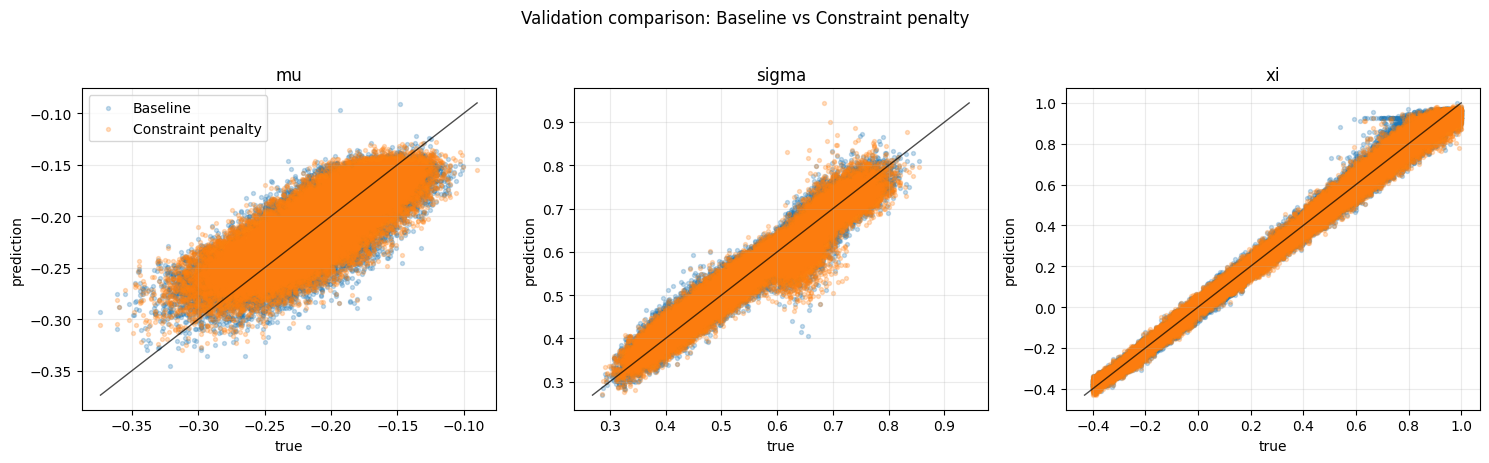

WindowsPath('c:/Users/User.DESKTOP-4RV84M1/Desktop/論文/fast parameter estimate/fast_parameter_using_NN/results/figures/constraint_penalty_validation_1x3.png')

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
params = ["mu", "sigma", "xi"]

for ax, param in zip(axes, params):
    ax.scatter(
        true_params[param], baseline_params[param],
        s=8, alpha=0.25, label="Baseline"
    )
    ax.scatter(
        true_params[param], constraint_params[param],
        s=8, alpha=0.25, label="Constraint penalty"
    )
    lo = min(true_params[param].min(), baseline_params[param].min(), constraint_params[param].min())
    hi = max(true_params[param].max(), baseline_params[param].max(), constraint_params[param].max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1, alpha=0.7)
    ax.set_title(param)
    ax.set_xlabel("true")
    ax.set_ylabel("prediction")
    ax.grid(alpha=0.25)

axes[0].legend(loc="best")
fig.suptitle("Validation comparison: Baseline vs Constraint penalty", y=1.02)
fig.tight_layout()

figure_path = FIGURE_DIR / "constraint_penalty_validation_1x3.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

figure_path

## Separate Grid Search: $\xi$ Margin vs. $\exp(\delta)$ Margin

前面的比較只看單一 safety margin。這一段將兩種限制分開比較：

```text
1. xi margin: vary m, keep delta margin = 0
2. delta margin: vary exp(delta) lower bound, keep xi margin = 0
```

這樣才能判斷哪一種 constraint 對 parameter RMSE 與 return level RMSE 比較有幫助。因為每個設定都需要重新訓練一個模型，所以這段預設不會自動重訓。


In [8]:
XI_MARGIN_GRID = [0.0, 0.01, 0.03, 0.05]
DELTA_MARGIN_GRID = [0.0, 0.01, 0.03, 0.05]
RUN_XI_GRID_SEARCH = False
RUN_DELTA_GRID_SEARCH = False

if RUN_XI_GRID_SEARCH:
    from grid_search_safety_margin import run_grid_search
    grid_metrics, grid_summary = run_grid_search(
        mode="xi",
        margins=XI_MARGIN_GRID,
        delta_margins=[0.0],
        penalty_weight=0.1,
        epochs=150,
        patience=8,
        seed=111,
    )
elif RUN_DELTA_GRID_SEARCH:
    from grid_search_safety_margin import run_grid_search
    grid_metrics, grid_summary = run_grid_search(
        mode="delta",
        margins=[0.0],
        delta_margins=DELTA_MARGIN_GRID,
        penalty_weight=0.1,
        epochs=150,
        patience=8,
        seed=111,
    )
else:
    print("若要在 notebook 內重訓 xi margin grid search，請把 RUN_XI_GRID_SEARCH 改成 True。")
    print("若要在 notebook 內重訓 delta margin grid search，請把 RUN_DELTA_GRID_SEARCH 改成 True。")
    print("或先在 PowerShell 分別執行：")
    print("python src/grid_search_safety_margin.py --mode xi --margins 0.0,0.01,0.03,0.05")
    print("python src/grid_search_safety_margin.py --mode delta --delta-margins 0.0,0.01,0.03,0.05")


若要在 notebook 內重訓 xi margin grid search，請把 RUN_XI_GRID_SEARCH 改成 True。
若要在 notebook 內重訓 delta margin grid search，請把 RUN_DELTA_GRID_SEARCH 改成 True。
或先在 PowerShell 分別執行：
python src/grid_search_safety_margin.py --mode xi --margins 0.0,0.01,0.03,0.05
python src/grid_search_safety_margin.py --mode delta --delta-margins 0.0,0.01,0.03,0.05


## 讀取 Grid Search 結果

如果已經跑過 `src/grid_search_safety_margin.py`，這裡會讀取輸出的 summary 和 metrics。


In [9]:
summary_frames = [pd.read_csv(path) for path in GRID_SEARCH_SUMMARY_PATHS if path.exists()]
metric_frames = [pd.read_csv(path) for path in GRID_SEARCH_METRICS_PATHS if path.exists()]

if summary_frames and metric_frames:
    grid_summary = pd.concat(summary_frames, ignore_index=True)
    grid_metrics = pd.concat(metric_frames, ignore_index=True)
    display(grid_summary.round(6))
else:
    grid_summary = None
    grid_metrics = None
    print("尚未找到 xi/delta grid search 結果。請先分別執行 xi 與 delta grid search。")


,method,safety_margin,delta_margin,violation_rate,delta_violation_rate,min_lower_margin,min_upper_margin,min_delta_slack,mean_interval_width,experiment,rmse_score,return_level_rmse_score,xi_rmse,rl100_rmse,model_path,history_path
0,Baseline,0.00,0.00,0.000000,0.000000,0.014473,0.115243,0.031869,0.797132,xi_margin,NaN,NaN,NaN,NaN,NaN,NaN
1,Constraint penalty,0.00,0.00,0.000000,0.000000,0.012516,0.121010,0.027366,0.791546,xi_margin,0.087757,3.652992,0.034998,2.365951,C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...,C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...
2,Baseline,0.01,0.00,0.000000,0.000000,0.004473,0.105244,0.031869,0.777132,xi_margin,NaN,NaN,NaN,NaN,NaN,NaN
3,Constraint penalty,0.01,0.00,0.000000,0.000000,0.003047,0.103727,0.028746,0.771828,xi_margin,0.085043,3.481323,0.034074,2.257118,C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...,C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...
4,Baseline,0.03,0.00,0.027850,0.000000,-0.015527,0.085244,0.031869,0.737132,xi_margin,NaN,NaN,NaN,NaN,NaN,NaN
5,Constraint penalty,0.03,0.00,0.029950,0.000000,-0.015391,0.090094,0.031179,0.732634,xi_margin,0.085166,3.514394,0.034271,2.277775,C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...,C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...
6,Baseline,0.05,0.00,0.112925,0.000000,-0.035527,0.065244,0.031869,0.697132,xi_margin,NaN,NaN,NaN,NaN,NaN,NaN
7,Constraint penalty,0.05,0.00,0.123175,0.000000,-0.037233,-0.027120,0.006665,0.696378,xi_margin,0.087261,4.443984,0.036026,2.963301,C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...,C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...
8,Baseline,0.00,0.00,0.000000,0.000000,0.014473,0.115243,0.031869,0.797132,delta_margin,NaN,NaN,NaN,NaN,NaN,NaN
9,Constraint penalty,0.00,0.00,0.000000,0.000000,0.012516,0.121010,0.027366,0.791546,delta_margin,0.087757,3.652992,0.034998,2.365951,C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...,C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...


## 選擇最佳 Safety Margin

這裡用三個參數的 RMSE 加總作為簡單分數：

```text
score = RMSE_mu + RMSE_sigma + RMSE_xi
```

分數越小代表整體 RMSE 越好；但實際報告時也要同時看 $\xi$ 的 Bias 和 violation rate。


In [10]:
if grid_metrics is not None:
    constraint_metrics = grid_metrics[grid_metrics["method"] == "Constraint penalty"].copy()
    param_metrics = constraint_metrics[constraint_metrics["param"].isin(["mu", "sigma", "xi"])]
    rl_metrics = constraint_metrics[constraint_metrics["param"].isin(["RL10", "RL50", "RL100"])]

    param_pivot = param_metrics.pivot_table(
        index=["experiment", "safety_margin", "delta_margin"], columns="param", values="RMSE"
    ).reset_index()
    param_pivot["param_rmse_score"] = param_pivot[["mu", "sigma", "xi"]].sum(axis=1)

    rl_pivot = rl_metrics.pivot_table(
        index=["experiment", "safety_margin", "delta_margin"], columns="param", values="RMSE"
    ).reset_index()
    rl_pivot["return_level_rmse_score"] = rl_pivot[["RL10", "RL50", "RL100"]].sum(axis=1)

    violation = grid_summary[grid_summary["method"] == "Constraint penalty"][[
        "experiment", "safety_margin", "delta_margin", "violation_rate", "delta_violation_rate", "mean_interval_width"
    ]]
    grid_best_table = (
        param_pivot
        .merge(rl_pivot, on=["experiment", "safety_margin", "delta_margin"], how="left")
        .merge(violation, on=["experiment", "safety_margin", "delta_margin"], how="left")
        .sort_values("return_level_rmse_score")
    )
    display(grid_best_table.round(6))

    best = grid_best_table.iloc[0]
    print(
        f"Best setting by return-level RMSE: "
        f"experiment={best['experiment']}, m={best['safety_margin']}, delta_margin={best['delta_margin']}"
    )
else:
    print("沒有 grid search metrics 可整理。")


,experiment,safety_margin,delta_margin,mu,sigma,xi,param_rmse_score,RL10,RL100,RL50,return_level_rmse_score,violation_rate,delta_violation_rate,mean_interval_width
5,xi_margin,0.01,0.00,0.022695,0.028274,0.034074,0.085043,0.168116,2.257118,1.056088,3.481323,0.000000,0.000000,0.771828
6,xi_margin,0.03,0.00,0.022693,0.028203,0.034271,0.085166,0.170442,2.277775,1.066177,3.514394,0.029950,0.000000,0.732634
0,delta_margin,0.00,0.00,0.022682,0.030077,0.034998,0.087757,0.177521,2.365951,1.109521,3.652992,0.000000,0.000000,0.791546
4,xi_margin,0.00,0.00,0.022682,0.030077,0.034998,0.087757,0.177521,2.365951,1.109521,3.652992,0.000000,0.000000,0.791546
3,delta_margin,0.00,0.05,0.023026,0.028683,0.034551,0.086260,0.174819,2.375294,1.108869,3.658982,0.011625,0.011625,0.792946
1,delta_margin,0.00,0.01,0.023153,0.029993,0.037208,0.090354,0.195537,2.675486,1.253980,4.125003,0.000000,0.000000,0.792664
7,xi_margin,0.05,0.00,0.023319,0.027916,0.036026,0.087261,0.188069,2.963301,1.292614,4.443984,0.123175,0.000000,0.696378
2,delta_margin,0.00,0.03,0.023521,0.028376,0.036658,0.088554,0.195816,3.219756,1.362295,4.777867,0.000100,0.000100,0.797603


Best setting by return-level RMSE: experiment=xi_margin, m=0.01, delta_margin=0.0


## Grid Search 圖形比較

這張 1 x 3 圖顯示不同 safety margin 對 $\mu$、$\sigma$、$\xi$ RMSE 的影響。


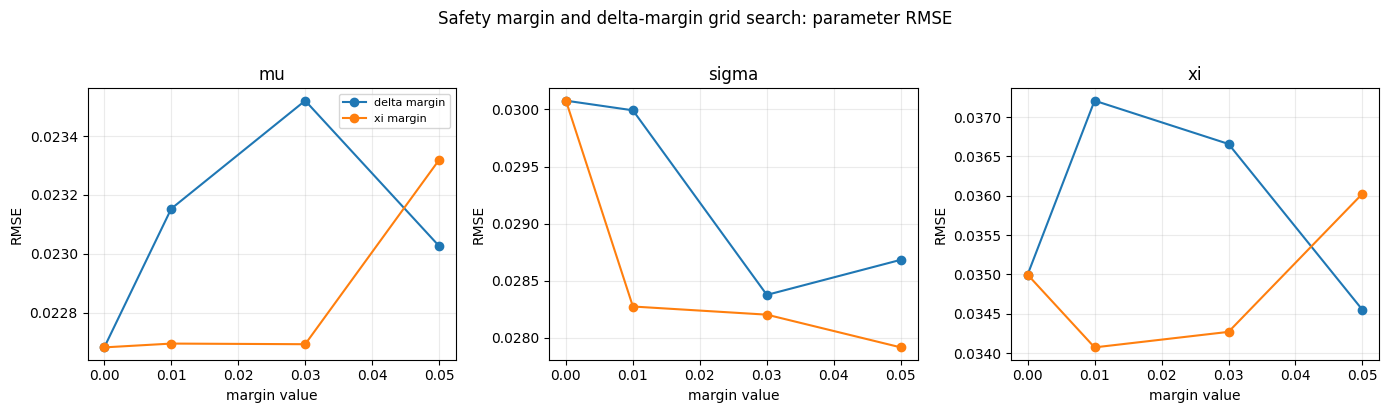

In [11]:
if grid_metrics is not None:
    constraint_metrics = grid_metrics[grid_metrics["method"] == "Constraint penalty"].copy()
    param_metrics = constraint_metrics[constraint_metrics["param"].isin(["mu", "sigma", "xi"])]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, param in zip(axes, ["mu", "sigma", "xi"]):
        sub = param_metrics[param_metrics["param"] == param].copy()
        for experiment, group in sub.groupby("experiment"):
            if experiment == "xi_margin":
                x_col = "safety_margin"
                label = "xi margin"
            else:
                x_col = "delta_margin"
                label = "delta margin"
            group = group.sort_values(x_col)
            ax.plot(group[x_col], group["RMSE"], marker="o", label=label)
        ax.set_title(param)
        ax.set_xlabel("margin value")
        ax.set_ylabel("RMSE")
        ax.grid(alpha=0.25)
    axes[0].legend(fontsize=8)
    fig.suptitle("Safety margin and delta-margin grid search: parameter RMSE", y=1.02)
    fig.tight_layout()
    grid_fig_path = FIGURE_DIR / "safety_delta_grid_search_param_rmse_1x3.png"
    fig.savefig(grid_fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    grid_fig_path
else:
    print("沒有 grid search metrics 可畫圖。")


## Return Level Grid Search 圖形比較

這張 1 x 3 圖顯示不同設定對 10、50、100 年 return level RMSE 的影響，用來檢查極端事件是否被忽略或壓低。


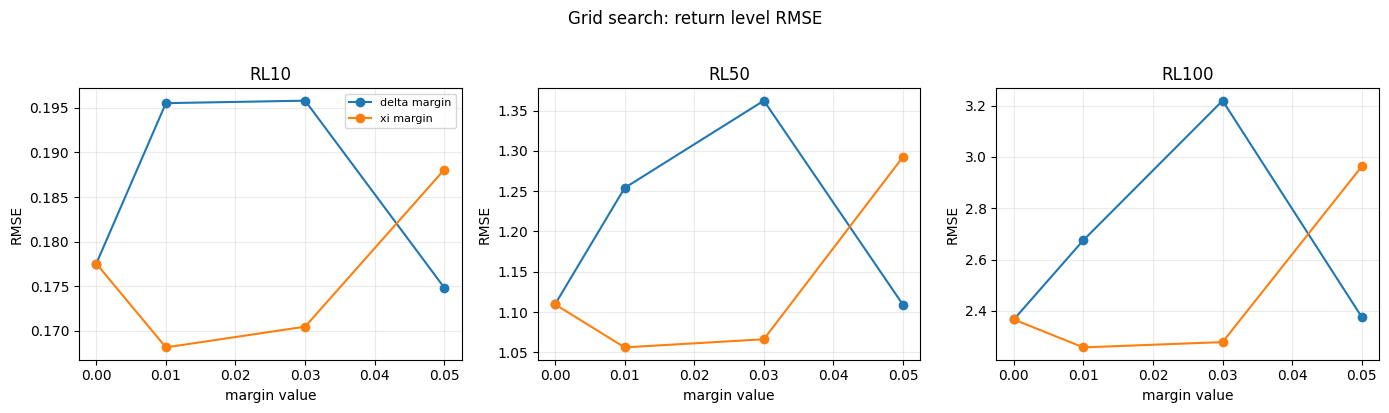

In [12]:
if grid_metrics is not None:
    constraint_metrics = grid_metrics[grid_metrics["method"] == "Constraint penalty"].copy()
    rl_metrics = constraint_metrics[constraint_metrics["param"].isin(["RL10", "RL50", "RL100"])]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, param in zip(axes, ["RL10", "RL50", "RL100"]):
        sub = rl_metrics[rl_metrics["param"] == param].copy()
        for experiment, group in sub.groupby("experiment"):
            if experiment == "xi_margin":
                x_col = "safety_margin"
                label = "xi margin"
            else:
                x_col = "delta_margin"
                label = "delta margin"
            group = group.sort_values(x_col)
            ax.plot(group[x_col], group["RMSE"], marker="o", label=label)
        ax.set_title(param)
        ax.set_xlabel("margin value")
        ax.set_ylabel("RMSE")
        ax.grid(alpha=0.25)
    axes[0].legend(fontsize=8)
    fig.suptitle("Grid search: return level RMSE", y=1.02)
    fig.tight_layout()
    rl_fig_path = FIGURE_DIR / "safety_delta_grid_search_return_level_rmse_1x3.png"
    fig.savefig(rl_fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    rl_fig_path
else:
    print("沒有 grid search metrics 可畫 return level 圖。")


## Paired Significance Tests

這裡檢驗加入 $\xi$ safety margin 或 $\exp(\delta)$ margin 後，RMSE 的改善是否只是抽樣波動。

虛無假設為 $H_0: RMSE_{candidate} \ge RMSE_{baseline}$，對立假設為 $H_1: RMSE_{candidate} < RMSE_{baseline}$。檢定使用 paired bootstrap RMSE difference、paired squared-error t-test，以及 Holm multiple-testing correction。


In [ ]:
SIGNIFICANCE_PATH = TABLE_DIR / "constraint_significance_tests.csv"

if SIGNIFICANCE_PATH.exists():
    significance = pd.read_csv(SIGNIFICANCE_PATH)
    significance_table = significance[[
        "comparison", "target", "baseline_rmse", "candidate_rmse",
        "rmse_difference", "improvement_pct", "bootstrap_ci_low",
        "bootstrap_ci_high", "p_value_holm", "significant_improvement_0.05"
    ]]
    display(significance_table.round(6))
else:
    print("尚未找到顯著性檢定結果，請先執行：")
    print("python src/test_constraint_significance.py --bootstrap 2000")


## 輸出檔案

執行完 notebook 後會產生：

- `results/tables/constraint_penalty_validation_metrics.csv`
- `results/tables/constraint_penalty_violation_summary.csv`
- `results/figures/constraint_penalty_validation_1x3.png`

如果執行 safety margin grid search，也會產生：

- `results/tables/safety_margin_grid_search_xi_summary.csv`
- `results/tables/safety_margin_grid_search_xi_metrics.csv`
- `results/tables/safety_margin_grid_search_delta_summary.csv`
- `results/tables/safety_margin_grid_search_delta_metrics.csv`
- `results/figures/safety_delta_grid_search_param_rmse_1x3.png`
- `results/figures/safety_delta_grid_search_return_level_rmse_1x3.png`

如果 constraint penalty 模型有效，理想上會看到 violation rate 降低，同時 $\mu^*$、$\sigma^*$、$\xi$ 的誤差不要明顯變差。
